In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy.stats import zscore
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from catboost import CatBoostRegressor
import lightgbm as lgb
import re
import xgboost as xgb
from xgboost import XGBRegressor

In [2]:
train=pd.read_csv('train.csv')
test=pd.read_csv('test.csv')
macro=pd.read_csv('macro.csv')

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
train.info(verbose=True, memory_usage='deep')
train.head()

<class 'pandas.DataFrame'>
RangeIndex: 30471 entries, 0 to 30470
Data columns (total 292 columns):
 #    Column                                 Dtype  
---   ------                                 -----  
 0    id                                     int64  
 1    timestamp                              str    
 2    full_sq                                int64  
 3    life_sq                                float64
 4    floor                                  float64
 5    max_floor                              float64
 6    material                               float64
 7    build_year                             float64
 8    num_room                               float64
 9    kitch_sq                               float64
 10   state                                  float64
 11   product_type                           str    
 12   sub_area                               str    
 13   area_m                                 float64
 14   raion_popul                            int64  


,id,timestamp,full_sq,life_sq,floor,max_floor,material,build_year,num_room,kitch_sq,state,product_type,sub_area,area_m,raion_popul,green_zone_part,indust_part,children_preschool,preschool_quota,preschool_education_centers_raion,children_school,school_quota,school_education_centers_raion,school_education_centers_top_20_raion,hospital_beds_raion,healthcare_centers_raion,university_top_20_raion,sport_objects_raion,additional_education_raion,culture_objects_top_25,culture_objects_top_25_raion,shopping_centers_raion,office_raion,thermal_power_plant_raion,incineration_raion,oil_chemistry_raion,radiation_raion,railroad_terminal_raion,big_market_raion,nuclear_reactor_raion,detention_facility_raion,full_all,male_f,female_f,young_all,young_male,young_female,work_all,work_male,work_female,ekder_all,ekder_male,ekder_female,0_6_all,0_6_male,0_6_female,7_14_all,7_14_male,7_14_female,0_17_all,0_17_male,0_17_female,16_29_all,16_29_male,16_29_female,0_13_all,0_13_male,0_13_female,raion_build_count_with_material_info,build_count_block,build_count_wood,build_count_frame,build_count_brick,build_count_monolith,build_count_panel,build_count_foam,build_count_slag,build_count_mix,raion_build_count_with_builddate_info,build_count_before_1920,build_count_1921-1945,build_count_1946-1970,build_count_1971-1995,build_count_after_1995,ID_metro,metro_min_avto,metro_km_avto,metro_min_walk,metro_km_walk,kindergarten_km,school_km,park_km,green_zone_km,industrial_km,water_treatment_km,cemetery_km,incineration_km,railroad_station_walk_km,railroad_station_walk_min,ID_railroad_station_walk,railroad_station_avto_km,railroad_station_avto_min,ID_railroad_station_avto,public_transport_station_km,public_transport_station_min_walk,water_km,water_1line,mkad_km,ttk_km,sadovoe_km,bulvar_ring_km,kremlin_km,big_road1_km,ID_big_road1,big_road1_1line,big_road2_km,ID_big_road2,railroad_km,railroad_1line,zd_vokzaly_avto_km,ID_railroad_terminal,bus_terminal_avto_km,ID_bus_terminal,oil_chemistry_km,nuclear_reactor_km,radiation_km,power_transmission_line_km,thermal_power_plant_km,ts_km,big_market_km,market_shop_km,fitness_km,swim_pool_km,ice_rink_km,stadium_km,basketball_km,hospice_morgue_km,detention_facility_km,public_healthcare_km,university_km,workplaces_km,shopping_centers_km,office_km,additional_education_km,preschool_km,big_church_km,church_synagogue_km,mosque_km,theater_km,museum_km,exhibition_km,catering_km,ecology,green_part_500,prom_part_500,office_count_500,office_sqm_500,trc_count_500,trc_sqm_500,cafe_count_500,cafe_sum_500_min_price_avg,cafe_sum_500_max_price_avg,cafe_avg_price_500,cafe_count_500_na_price,cafe_count_500_price_500,cafe_count_500_price_1000,cafe_count_500_price_1500,cafe_count_500_price_2500,cafe_count_500_price_4000,cafe_count_500_price_high,big_church_count_500,church_count_500,mosque_count_500,leisure_count_500,sport_count_500,market_count_500,green_part_1000,prom_part_1000,office_count_1000,office_sqm_1000,trc_count_1000,trc_sqm_1000,cafe_count_1000,cafe_sum_1000_min_price_avg,cafe_sum_1000_max_price_avg,cafe_avg_price_1000,cafe_count_1000_na_price,cafe_count_1000_price_500,cafe_count_1000_price_1000,cafe_count_1000_price_1500,cafe_count_1000_price_2500,cafe_count_1000_price_4000,cafe_count_1000_price_high,big_church_count_1000,church_count_1000,mosque_count_1000,leisure_count_1000,sport_count_1000,market_count_1000,green_part_1500,prom_part_1500,office_count_1500,office_sqm_1500,trc_count_1500,trc_sqm_1500,cafe_count_1500,cafe_sum_1500_min_price_avg,cafe_sum_1500_max_price_avg,cafe_avg_price_1500,cafe_count_1500_na_price,cafe_count_1500_price_500,cafe_count_1500_price_1000,cafe_count_1500_price_1500,cafe_count_1500_price_2500,cafe_count_1500_price_4000,cafe_count_1500_price_high,big_church_count_1500,church_count_1500,mosque_count_1500,leisure_count_1500,sport_count_1500,market_count_1500,green_part_2000,prom_part_2000,office_count_2000,office_sqm_2000,trc_count_2000,trc_sqm_2000,cafe_count_2000,cafe_sum_2000_min_price_avg,cafe_sum_2000_max_price_av

In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
test.info(verbose=True, memory_usage='deep')
test.head()


<class 'pandas.DataFrame'>
RangeIndex: 7662 entries, 0 to 7661
Data columns (total 291 columns):
 #    Column                                 Dtype  
---   ------                                 -----  
 0    id                                     int64  
 1    timestamp                              str    
 2    full_sq                                float64
 3    life_sq                                float64
 4    floor                                  int64  
 5    max_floor                              int64  
 6    material                               int64  
 7    build_year                             float64
 8    num_room                               int64  
 9    kitch_sq                               float64
 10   state                                  float64
 11   product_type                           str    
 12   sub_area                               str    
 13   area_m                                 float64
 14   raion_popul                            int64  
 1

,id,timestamp,full_sq,life_sq,floor,max_floor,material,build_year,num_room,kitch_sq,state,product_type,sub_area,area_m,raion_popul,green_zone_part,indust_part,children_preschool,preschool_quota,preschool_education_centers_raion,children_school,school_quota,school_education_centers_raion,school_education_centers_top_20_raion,hospital_beds_raion,healthcare_centers_raion,university_top_20_raion,sport_objects_raion,additional_education_raion,culture_objects_top_25,culture_objects_top_25_raion,shopping_centers_raion,office_raion,thermal_power_plant_raion,incineration_raion,oil_chemistry_raion,radiation_raion,railroad_terminal_raion,big_market_raion,nuclear_reactor_raion,detention_facility_raion,full_all,male_f,female_f,young_all,young_male,young_female,work_all,work_male,work_female,ekder_all,ekder_male,ekder_female,0_6_all,0_6_male,0_6_female,7_14_all,7_14_male,7_14_female,0_17_all,0_17_male,0_17_female,16_29_all,16_29_male,16_29_female,0_13_all,0_13_male,0_13_female,raion_build_count_with_material_info,build_count_block,build_count_wood,build_count_frame,build_count_brick,build_count_monolith,build_count_panel,build_count_foam,build_count_slag,build_count_mix,raion_build_count_with_builddate_info,build_count_before_1920,build_count_1921-1945,build_count_1946-1970,build_count_1971-1995,build_count_after_1995,ID_metro,metro_min_avto,metro_km_avto,metro_min_walk,metro_km_walk,kindergarten_km,school_km,park_km,green_zone_km,industrial_km,water_treatment_km,cemetery_km,incineration_km,railroad_station_walk_km,railroad_station_walk_min,ID_railroad_station_walk,railroad_station_avto_km,railroad_station_avto_min,ID_railroad_station_avto,public_transport_station_km,public_transport_station_min_walk,water_km,water_1line,mkad_km,ttk_km,sadovoe_km,bulvar_ring_km,kremlin_km,big_road1_km,ID_big_road1,big_road1_1line,big_road2_km,ID_big_road2,railroad_km,railroad_1line,zd_vokzaly_avto_km,ID_railroad_terminal,bus_terminal_avto_km,ID_bus_terminal,oil_chemistry_km,nuclear_reactor_km,radiation_km,power_transmission_line_km,thermal_power_plant_km,ts_km,big_market_km,market_shop_km,fitness_km,swim_pool_km,ice_rink_km,stadium_km,basketball_km,hospice_morgue_km,detention_facility_km,public_healthcare_km,university_km,workplaces_km,shopping_centers_km,office_km,additional_education_km,preschool_km,big_church_km,church_synagogue_km,mosque_km,theater_km,museum_km,exhibition_km,catering_km,ecology,green_part_500,prom_part_500,office_count_500,office_sqm_500,trc_count_500,trc_sqm_500,cafe_count_500,cafe_sum_500_min_price_avg,cafe_sum_500_max_price_avg,cafe_avg_price_500,cafe_count_500_na_price,cafe_count_500_price_500,cafe_count_500_price_1000,cafe_count_500_price_1500,cafe_count_500_price_2500,cafe_count_500_price_4000,cafe_count_500_price_high,big_church_count_500,church_count_500,mosque_count_500,leisure_count_500,sport_count_500,market_count_500,green_part_1000,prom_part_1000,office_count_1000,office_sqm_1000,trc_count_1000,trc_sqm_1000,cafe_count_1000,cafe_sum_1000_min_price_avg,cafe_sum_1000_max_price_avg,cafe_avg_price_1000,cafe_count_1000_na_price,cafe_count_1000_price_500,cafe_count_1000_price_1000,cafe_count_1000_price_1500,cafe_count_1000_price_2500,cafe_count_1000_price_4000,cafe_count_1000_price_high,big_church_count_1000,church_count_1000,mosque_count_1000,leisure_count_1000,sport_count_1000,market_count_1000,green_part_1500,prom_part_1500,office_count_1500,office_sqm_1500,trc_count_1500,trc_sqm_1500,cafe_count_1500,cafe_sum_1500_min_price_avg,cafe_sum_1500_max_price_avg,cafe_avg_price_1500,cafe_count_1500_na_price,cafe_count_1500_price_500,cafe_count_1500_price_1000,cafe_count_1500_price_1500,cafe_count_1500_price_2500,cafe_count_1500_price_4000,cafe_count_1500_price_high,big_church_count_1500,church_count_1500,mosque_count_1500,leisure_count_1500,sport_count_1500,market_count_1500,green_part_2000,prom_part_2000,office_count_2000,office_sqm_2000,trc_count_2000,trc_sqm_2000,cafe_count_2000,cafe_sum_2000_min_price_avg,cafe_sum_2000_max_price_av

In [5]:
macro.head()
macro.info()

<class 'pandas.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 100 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   timestamp                                   2484 non-null   str    
 1   oil_urals                                   2484 non-null   float64
 2   gdp_quart                                   2394 non-null   float64
 3   gdp_quart_growth                            2394 non-null   float64
 4   cpi                                         2453 non-null   float64
 5   ppi                                         2453 non-null   float64
 6   gdp_deflator                                2119 non-null   float64
 7   balance_trade                               2453 non-null   float64
 8   balance_trade_growth                        2394 non-null   float64
 9   usdrub                                      2481 non-null   float64
 10  eurrub                

In [6]:
train['timestamp']=pd.to_datetime(train['timestamp'])
test['timestamp']=pd.to_datetime(test['timestamp'])
macro['timestamp']=pd.to_datetime(macro['timestamp'])
macro = macro.ffill().bfill()

In [7]:
train = pd.merge(train, macro, on='timestamp', how='left')
test = pd.merge(test, macro, on='timestamp', how='left')

In [8]:

categorical_cols = ['material', 'state', 'product_type', 'sub_area']
for df in [train, test]:
    for col in categorical_cols:
        if col in df.columns and df[col].isna().any():
            df[col] = df[col].fillna(df[col].mode()[0]) 

numeric_cols = [c for c in train.select_dtypes(include='number').columns 
                if c not in ['id', 'price_doc']]
for col in numeric_cols:
    for df in [train, test]:
        if col in df.columns and df[col].isna().any():
            df[col] = df[col].fillna(df[col].median())  


train.isnull().sum().sort_values(ascending=False).head(40)

id                                       0
timestamp                                0
full_sq                                  0
life_sq                                  0
floor                                    0
max_floor                                0
material                                 0
build_year                               0
num_room                                 0
kitch_sq                                 0
state                                    0
product_type                             0
sub_area                                 0
area_m                                   0
raion_popul                              0
green_zone_part                          0
indust_part                              0
children_preschool                       0
preschool_quota                          0
preschool_education_centers_raion        0
children_school                          0
school_quota                             0
school_education_centers_raion           0
school_educ

In [9]:
train.shape

(30471, 391)

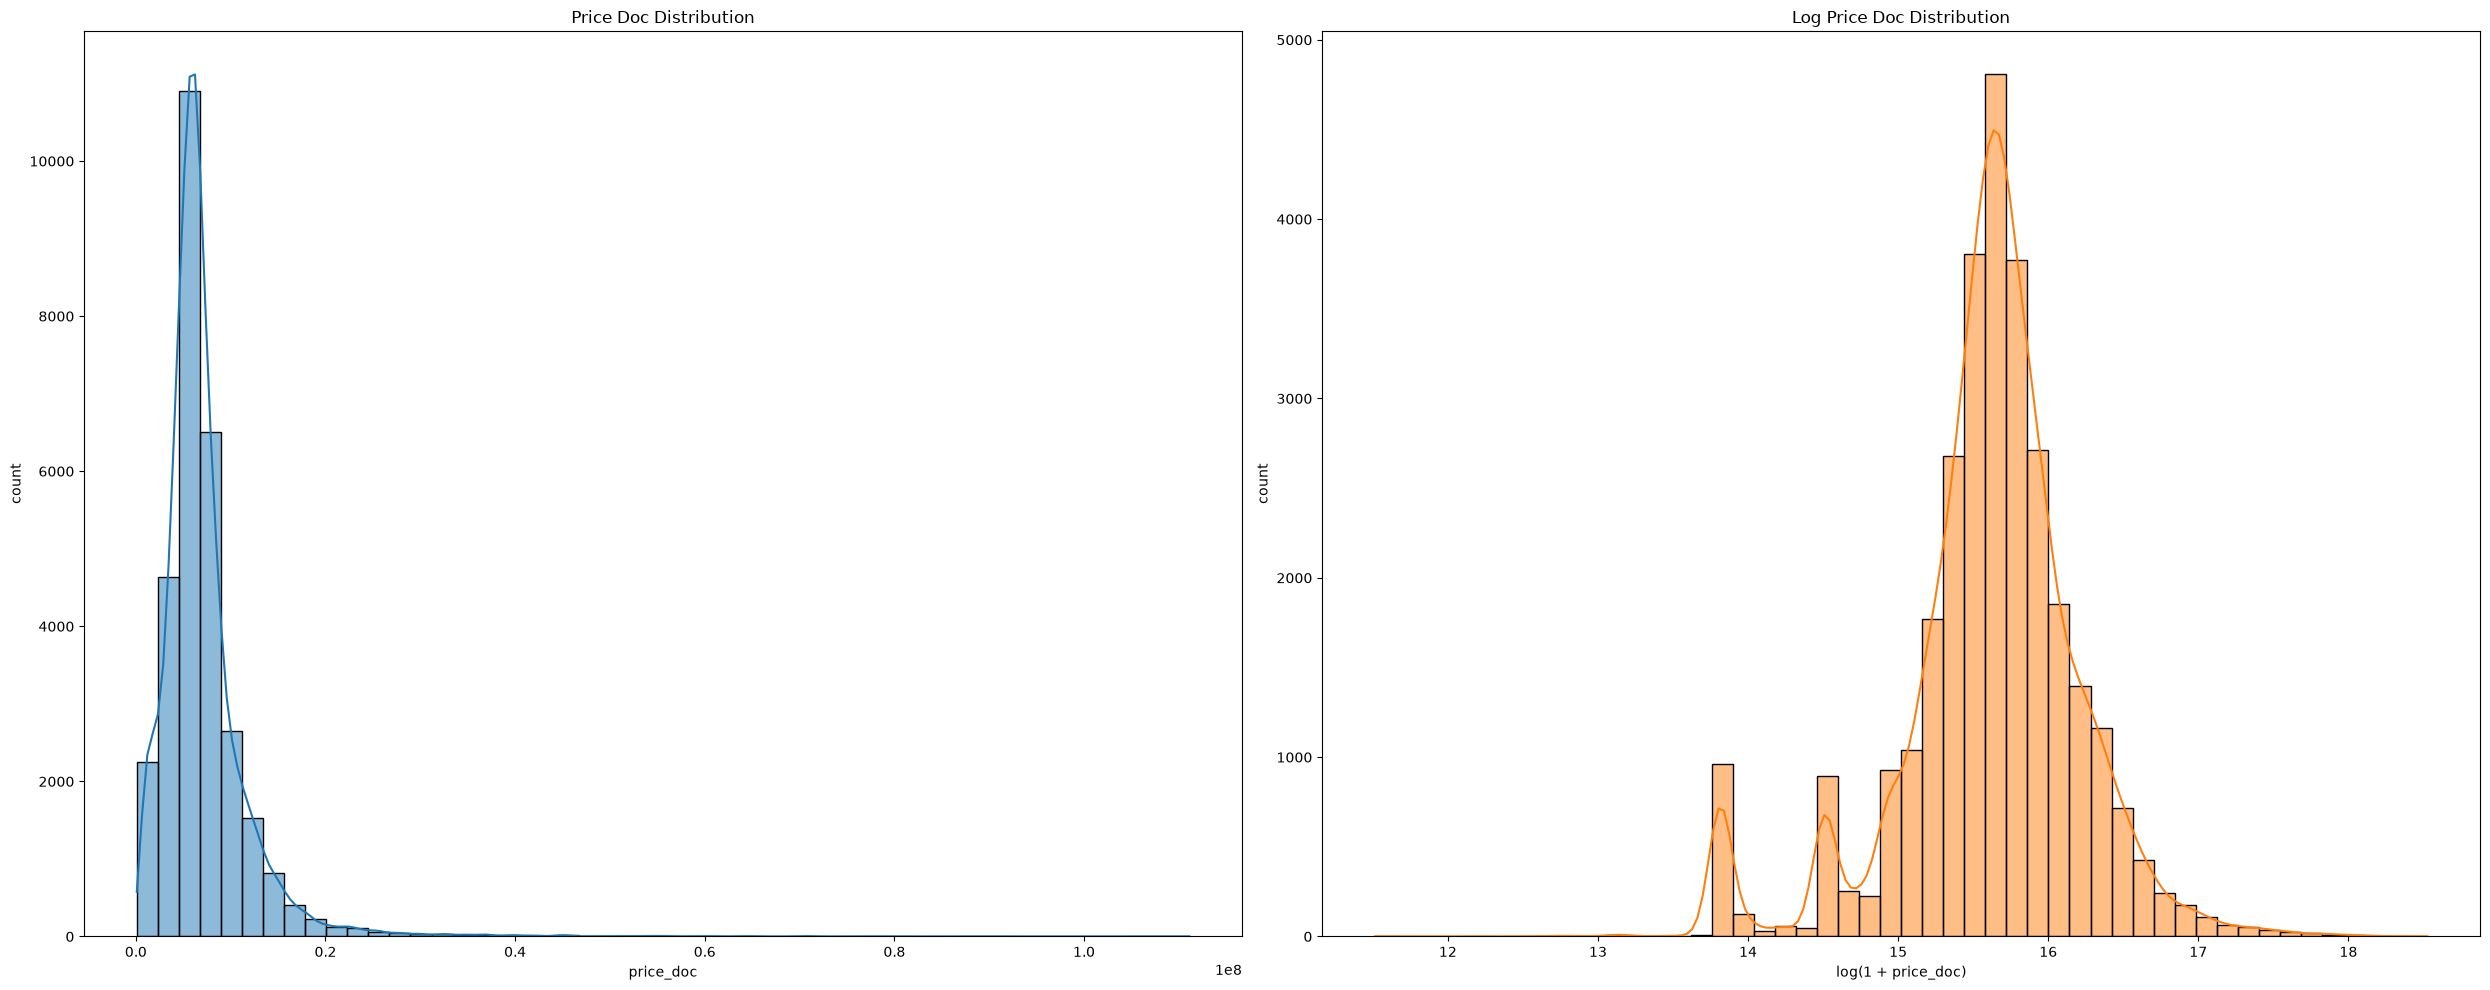

Normal distribution skewness is: 4.4747
Log-transformed distribution skewness is: -0.6867


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(25, 10))

sns.histplot(train['price_doc'], bins=50, color='tab:blue', kde=True, ax=axes[0])
axes[0].set_title('Price Doc Distribution')
axes[0].set_xlabel('price_doc')
axes[0].set_ylabel('count')

sns.histplot(np.log1p(train['price_doc']), bins=50, color='tab:orange', kde=True, ax=axes[1])
axes[1].set_title('Log Price Doc Distribution')
axes[1].set_xlabel('log(1 + price_doc)')
axes[1].set_ylabel('count')

plt.tight_layout()
plt.show()
skewness = train['price_doc'].skew()
log_skewness = np.log1p(train['price_doc']).skew()
print(f'Normal distribution skewness is: {skewness:.4f}')
print(f'Log-transformed distribution skewness is: {log_skewness:.4f}')

C:\Users\wafaa\AppData\Local\Temp\ipykernel_5780\2047558255.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr_features.values, y=top_corr_features.index ,palette='viridis')


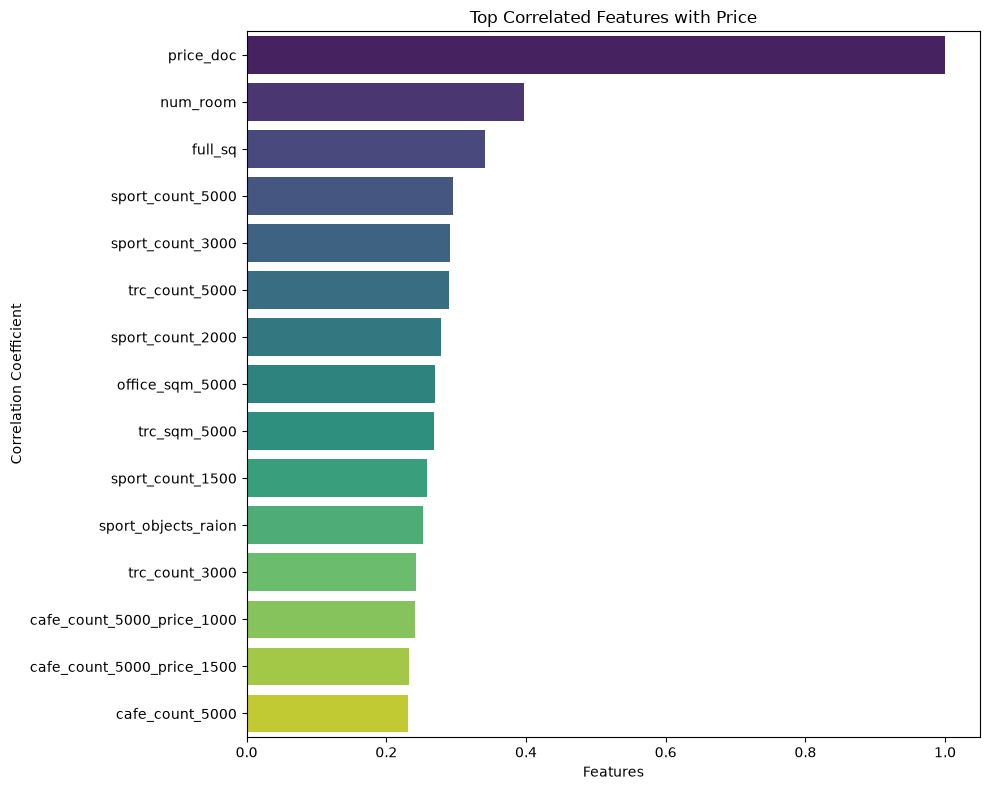

price_doc                     1.000000
num_room                      0.397644
full_sq                       0.341840
sport_count_5000              0.294864
sport_count_3000              0.290651
trc_count_5000                0.289371
sport_count_2000              0.278056
office_sqm_5000               0.269977
trc_sqm_5000                  0.268072
sport_count_1500              0.258376
sport_objects_raion           0.252794
trc_count_3000                0.242068
cafe_count_5000_price_1000    0.240464
cafe_count_5000_price_1500    0.232612
cafe_count_5000               0.231546
Name: price_doc, dtype: float64


In [11]:
corr_matrix = train.corr(numeric_only=True)
top_corr_features = corr_matrix['price_doc'].sort_values(ascending=False).head(15)
plt.figure(figsize=(10,8))
sns.barplot(x=top_corr_features.values, y=top_corr_features.index ,palette='viridis')
plt.title('Top Correlated Features with Price')
plt.ylabel('Correlation Coefficient')
plt.xlabel('Features')
plt.tight_layout()
plt.show()
print(top_corr_features)

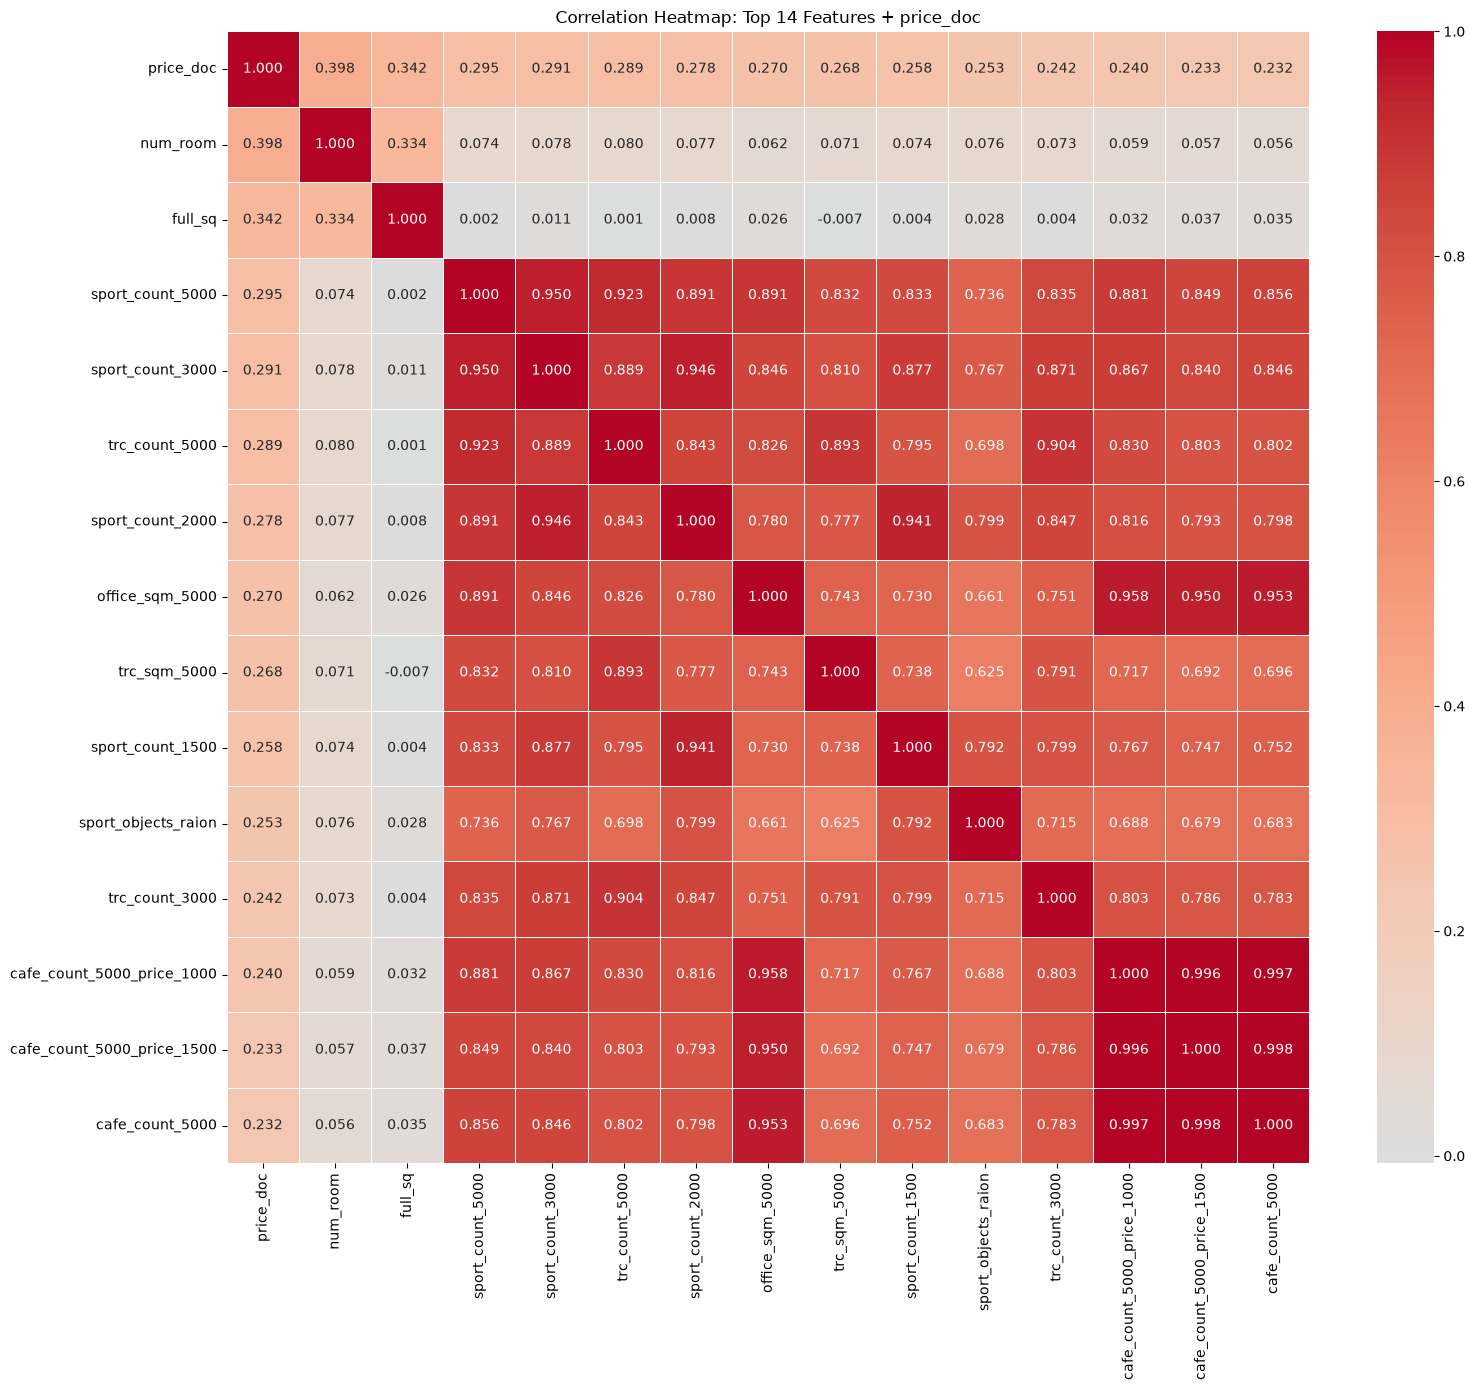

In [12]:
feature_names = [f for f in top_corr_features.index if f != 'price_doc'][:14]
cols_for_heatmap = ['price_doc'] + feature_names
df_subset = train[cols_for_heatmap]
corr_subset = df_subset.corr()
plt.figure(figsize=(16, 14))
sns.heatmap(corr_subset, annot=True, cmap='coolwarm', linewidths=0.5, fmt=".3f", center=0)
plt.title('Correlation Heatmap: Top 14 Features + price_doc')
plt.tight_layout()
plt.show()

In [13]:


feature_names = [f for f in corr_subset.columns if f != 'price_doc']

pairs = []
for i in range(len(feature_names)):
    for j in range(i+1, len(feature_names)):
        f1, f2 = feature_names[i], feature_names[j]
        val = corr_subset.loc[f1, f2]
        if abs(val) > 0.80:
            corr_f1 = abs(corr_subset.loc['price_doc', f1])
            corr_f2 = abs(corr_subset.loc['price_doc', f2])
            keep = f1 if corr_f1 >= corr_f2 else f2
            drop = f2 if keep == f1 else f1
            pairs.append({
                'Feature 1': f1,
                'Feature 2': f2,
                'Correlation': round(val, 3),
                'F1 vs price': round(corr_f1, 3),
                'F2 vs price': round(corr_f2, 3),
                'KEEP (stronger)': keep,
                'DROP (weaker)': drop
            })

df_pairs = pd.DataFrame(pairs)



if len(pairs) > 0:
    to_drop = set()
    for p in pairs:
        to_drop.add(p['DROP (weaker)'])
    
 
    for feat in feature_names:
        corr_price = abs(corr_subset.loc['price_doc', feat])
        action = "❌ DROP" if feat in to_drop else "✅ KEEP"
        print(f"{feat:<25} {corr_price:>15.3f} {action:>10}")
    print()
    print(f"💡 Total to drop: {len(to_drop)} | Total to keep: {len(feature_names) - len(to_drop)}")
    

num_room                            0.398     ✅ KEEP
full_sq                             0.342     ✅ KEEP
sport_count_5000                    0.295     ✅ KEEP
sport_count_3000                    0.291     ❌ DROP
trc_count_5000                      0.289     ❌ DROP
sport_count_2000                    0.278     ❌ DROP
office_sqm_5000                     0.270     ❌ DROP
trc_sqm_5000                        0.268     ❌ DROP
sport_count_1500                    0.258     ❌ DROP
sport_objects_raion                 0.253     ✅ KEEP
trc_count_3000                      0.242     ❌ DROP
cafe_count_5000_price_1000           0.240     ❌ DROP
cafe_count_5000_price_1500           0.233     ❌ DROP
cafe_count_5000                     0.232     ❌ DROP

💡 Total to drop: 10 | Total to keep: 4


In [14]:
train_clean = train.drop(columns=list(to_drop), errors='ignore')
test_clean = test.drop(columns=list(to_drop), errors='ignore')
    
print("✅ No highly correlated pairs found!")

✅ No highly correlated pairs found!


In [15]:
train.shape

(30471, 391)

In [16]:
train_clean.shape

(30471, 381)

In [17]:

for df in [train_clean, test_clean]:
   
    df['year'] = df['timestamp'].dt.year
    df['month'] = df['timestamp'].dt.month

    df['age_building'] = df['year'] - df['build_year']
    df['age_building'] = df['age_building'].where(df['age_building'] > 0, np.nan)
  
    df['full_sq_to_life_sq'] = df['full_sq'] / df['life_sq'].replace(0, np.nan)
    df['kitch_sq_to_full_sq'] = df['kitch_sq'] / df['full_sq'].replace(0, np.nan)
    df['floor_ratio'] = df['floor'] / df['max_floor'].replace(0, np.nan)
    df['area_per_room'] = df['life_sq'] / df['num_room'].replace(0, np.nan)
 
    for col in ['age_building', 'full_sq_to_life_sq', 'kitch_sq_to_full_sq', 
                'floor_ratio', 'area_per_room']:
        df[col] = df[col].replace([np.inf, -np.inf], np.nan)
        df[col] = df[col].fillna(df[col].median())

sub_area_mean = train.groupby('sub_area')['price_doc'].mean()
sub_area_median = train.groupby('sub_area')['price_doc'].median()

train['sub_area_price_mean'] = train['sub_area'].map(sub_area_mean)
train['sub_area_price_median'] = train['sub_area'].map(sub_area_median)

test['sub_area_price_mean'] = test['sub_area'].map(sub_area_mean)
test['sub_area_price_median'] = test['sub_area'].map(sub_area_median)

test['sub_area_price_mean'] = test['sub_area_price_mean'].fillna(train['price_doc'].median())
test['sub_area_price_median'] = test['sub_area_price_median'].fillna(train['price_doc'].median())

print('✅ Done!')

C:\Users\wafaa\AppData\Local\Temp\ipykernel_5780\457327757.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['year'] = df['timestamp'].dt.year
C:\Users\wafaa\AppData\Local\Temp\ipykernel_5780\457327757.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['month'] = df['timestamp'].dt.month
C:\Users\wafaa\AppData\Local\Temp\ipykernel_5780\457327757.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all col

✅ Done!


C:\Users\wafaa\AppData\Local\Temp\ipykernel_5780\457327757.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test['sub_area_price_mean'] = test['sub_area'].map(sub_area_mean)
C:\Users\wafaa\AppData\Local\Temp\ipykernel_5780\457327757.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test['sub_area_price_median'] = test['sub_area'].map(sub_area_median)


In [18]:
train_clean.head(2)


,id,timestamp,full_sq,life_sq,floor,max_floor,material,build_year,num_room,kitch_sq,state,product_type,sub_area,area_m,raion_popul,green_zone_part,indust_part,children_preschool,preschool_quota,preschool_education_centers_raion,children_school,school_quota,school_education_centers_raion,school_education_centers_top_20_raion,hospital_beds_raion,healthcare_centers_raion,university_top_20_raion,sport_objects_raion,additional_education_raion,culture_objects_top_25,culture_objects_top_25_raion,shopping_centers_raion,office_raion,thermal_power_plant_raion,incineration_raion,oil_chemistry_raion,radiation_raion,railroad_terminal_raion,big_market_raion,nuclear_reactor_raion,detention_facility_raion,full_all,male_f,female_f,young_all,young_male,young_female,work_all,work_male,work_female,ekder_all,ekder_male,ekder_female,0_6_all,0_6_male,0_6_female,7_14_all,7_14_male,7_14_female,0_17_all,0_17_male,0_17_female,16_29_all,16_29_male,16_29_female,0_13_all,0_13_male,0_13_female,raion_build_count_with_material_info,build_count_block,build_count_wood,build_count_frame,build_count_brick,build_count_monolith,build_count_panel,build_count_foam,build_count_slag,build_count_mix,raion_build_count_with_builddate_info,build_count_before_1920,build_count_1921-1945,build_count_1946-1970,build_count_1971-1995,build_count_after_1995,ID_metro,metro_min_avto,metro_km_avto,metro_min_walk,metro_km_walk,kindergarten_km,school_km,park_km,green_zone_km,industrial_km,water_treatment_km,cemetery_km,incineration_km,railroad_station_walk_km,railroad_station_walk_min,ID_railroad_station_walk,railroad_station_avto_km,railroad_station_avto_min,ID_railroad_station_avto,public_transport_station_km,public_transport_station_min_walk,water_km,water_1line,mkad_km,ttk_km,sadovoe_km,bulvar_ring_km,kremlin_km,big_road1_km,ID_big_road1,big_road1_1line,big_road2_km,ID_big_road2,railroad_km,railroad_1line,zd_vokzaly_avto_km,ID_railroad_terminal,bus_terminal_avto_km,ID_bus_terminal,oil_chemistry_km,nuclear_reactor_km,radiation_km,power_transmission_line_km,thermal_power_plant_km,ts_km,big_market_km,market_shop_km,fitness_km,swim_pool_km,ice_rink_km,stadium_km,basketball_km,hospice_morgue_km,detention_facility_km,public_healthcare_km,university_km,workplaces_km,shopping_centers_km,office_km,additional_education_km,preschool_km,big_church_km,church_synagogue_km,mosque_km,theater_km,museum_km,exhibition_km,catering_km,ecology,green_part_500,prom_part_500,office_count_500,office_sqm_500,trc_count_500,trc_sqm_500,cafe_count_500,cafe_sum_500_min_price_avg,cafe_sum_500_max_price_avg,cafe_avg_price_500,cafe_count_500_na_price,cafe_count_500_price_500,cafe_count_500_price_1000,cafe_count_500_price_1500,cafe_count_500_price_2500,cafe_count_500_price_4000,cafe_count_500_price_high,big_church_count_500,church_count_500,mosque_count_500,leisure_count_500,sport_count_500,market_count_500,green_part_1000,prom_part_1000,office_count_1000,office_sqm_1000,trc_count_1000,trc_sqm_1000,cafe_count_1000,cafe_sum_1000_min_price_avg,cafe_sum_1000_max_price_avg,cafe_avg_price_1000,cafe_count_1000_na_price,cafe_count_1000_price_500,cafe_count_1000_price_1000,cafe_count_1000_price_1500,cafe_count_1000_price_2500,cafe_count_1000_price_4000,cafe_count_1000_price_high,big_church_count_1000,church_count_1000,mosque_count_1000,leisure_count_1000,sport_count_1000,market_count_1000,green_part_1500,prom_part_1500,office_count_1500,office_sqm_1500,trc_count_1500,trc_sqm_1500,cafe_count_1500,cafe_sum_1500_min_price_avg,cafe_sum_1500_max_price_avg,cafe_avg_price_1500,cafe_count_1500_na_price,cafe_count_1500_price_500,cafe_count_1500_price_1000,cafe_count_1500_price_1500,cafe_count_1500_price_2500,cafe_count_1500_price_4000,cafe_count_1500_price_high,big_church_count_1500,church_count_1500,mosque_count_1500,leisure_count_1500,market_count_1500,green_part_2000,prom_part_2000,office_count_2000,office_sqm_2000,trc_count_2000,trc_sqm_2000,cafe_count_2000,cafe_sum_2000_min_price_avg,cafe_sum_2000_max_price_avg,cafe_avg_price_

In [19]:


before = len(train_clean)
print(f"Before removing outliers: {before}")
print("=" * 60)

# ==========================================
# 1. PHYSICAL RELATIONSHIPS
# ==========================================
train_clean['price_per_sqm'] = train_clean['price_doc'] / train_clean['full_sq']


# Rooms density: 5+ rooms in <50 sqm = غير منطقي
train_clean['rooms_density'] = train_clean['full_sq'] / train_clean['num_room']
conflict_rooms = (train_clean['num_room'] > 4) & (train_clean['rooms_density'] < 10)
print(f"1. Rooms too many for small area: {conflict_rooms.sum()}")
train_clean = train_clean[~conflict_rooms]

# Kitchen too big: >70% of living space
train_clean['kitchen_ratio'] = train_clean['kitch_sq'] / (train_clean['full_sq'] - train_clean['kitch_sq'])
conflict_kitchen = train_clean['kitchen_ratio'] > 0.7
print(f"2. Unusually large kitchen: {conflict_kitchen.sum()}")
train_clean = train_clean[~conflict_kitchen]

# ==========================================
# 2. LOCATION VS PRICE
# ==========================================

far_expensive = (train_clean['kremlin_km'] > 20) & \
                (train_clean['price_per_sqm'] > train_clean['price_per_sqm'].quantile(0.90))
print(f"3. Far from center but expensive: {far_expensive.sum()}")
train_clean = train_clean[~far_expensive]

# Near center (<2km) but cheap (<10th percentile)
near_cheap = (train_clean['kremlin_km'] < 2) & \
             (train_clean['price_per_sqm'] < train_clean['price_per_sqm'].quantile(0.10))
print(f"4. Near center but cheap: {near_cheap.sum()}")
train_clean = train_clean[~near_cheap]

# ==========================================
# 3. BUILDING AGE VS PRICE
# ==========================================

# Price deviation from build-year average
avg_price_by_year = train_clean.groupby('build_year')['price_per_sqm'].mean().reset_index()
avg_price_by_year.columns = ['build_year', 'avg_price_per_sqm']
train_clean = train_clean.merge(avg_price_by_year, on='build_year', how='left')

train_clean['year_price_deviation'] = train_clean['price_per_sqm'] - train_clean['avg_price_per_sqm']

# Outlier if >3 std from year average
train_clean['is_year_outlier'] = train_clean.groupby('build_year')['year_price_deviation'].transform(
    lambda x: np.abs(x) > (x.std() * 3)
)
print(f"5. Price deviating from build-year average: {train_clean['is_year_outlier'].sum()}")
train_clean = train_clean[~train_clean['is_year_outlier']]

# ==========================================
# 4. INFRASTRUCTURE VS PRICE RANK
# ==========================================

# Infrastructure score
train_clean['infra_score'] = (train_clean['cafe_count_500'].fillna(0) + 
                              train_clean['preschool_quota'].fillna(0) - 
                              train_clean['shopping_centers_km'].fillna(0))

# Rank within sub_area
train_clean['infra_rank'] = train_clean.groupby('sub_area')['infra_score'].rank(pct=True)
train_clean['price_rank'] = train_clean.groupby('sub_area')['price_per_sqm'].rank(pct=True)

# Gap between infra and price rank
train_clean['infra_price_gap'] = (train_clean['price_rank'] - train_clean['infra_rank']).abs()
infra_outliers = train_clean['infra_price_gap'] > 0.8
print(f"6. Infra rank doesn't match price rank: {infra_outliers.sum()}")
train_clean = train_clean[~infra_outliers]

# ==========================================
# SUMMARY
# ==========================================
after = len(train_clean)
print("=" * 60)
print(f"After removing outliers: {after}")
print(f"Removed: {before - after} rows ({(before-after)/before*100:.1f}%)")

Before removing outliers: 30471
1. Rooms too many for small area: 7


C:\Users\wafaa\AppData\Local\Temp\ipykernel_5780\4051579040.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_clean['price_per_sqm'] = train_clean['price_doc'] / train_clean['full_sq']
C:\Users\wafaa\AppData\Local\Temp\ipykernel_5780\4051579040.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_clean['rooms_density'] = train_clean['full_sq'] / train_clean['num_room']
C:\Users\wafaa\AppData\Local\Temp\ipykernel_5780\4051579040.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result o

2. Unusually large kitchen: 94
3. Far from center but expensive: 15
4. Near center but cheap: 54


C:\Users\wafaa\AppData\Local\Temp\ipykernel_5780\4051579040.py:47: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_clean['year_price_deviation'] = train_clean['price_per_sqm'] - train_clean['avg_price_per_sqm']
C:\Users\wafaa\AppData\Local\Temp\ipykernel_5780\4051579040.py:50: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_clean['is_year_outlier'] = train_clean.groupby('build_year')['year_price_deviation'].transform(


5. Price deviating from build-year average: 188


C:\Users\wafaa\AppData\Local\Temp\ipykernel_5780\4051579040.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_clean['infra_score'] = (train_clean['cafe_count_500'].fillna(0) +
C:\Users\wafaa\AppData\Local\Temp\ipykernel_5780\4051579040.py:66: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_clean['infra_rank'] = train_clean.groupby('sub_area')['infra_score'].rank(pct=True)
C:\Users\wafaa\AppData\Local\Temp\ipykernel_5780\4051579040.py:67: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result

6. Infra rank doesn't match price rank: 1213
After removing outliers: 28900
Removed: 1571 rows (5.2%)


In [20]:

if 'test_clean' not in globals():
    test_clean = test.copy()

object_cols = train_clean.select_dtypes(include=['object']).columns.tolist()

for col in object_cols:
    train_clean[col] = train_clean[col].astype('object')
    test_clean[col] = test_clean[col].astype('object')

x_train = train_clean.drop(['price_doc', 'id', 'timestamp'], axis=1)
y_train = np.log1p(train_clean['price_doc'])
x_test = test_clean.drop(['id', 'timestamp'], axis=1)

x_train_encoded = pd.get_dummies(x_train, columns=object_cols, drop_first=False)  # False أمان أكتر
x_test_encoded = pd.get_dummies(x_test, columns=object_cols, drop_first=False)

x_train_encoded, x_test_encoded = x_train_encoded.align(
    x_test_encoded, join='outer', axis=1, fill_value=0
)

x_train_encoded = x_train_encoded.fillna(0)
x_test_encoded = x_test_encoded.fillna(0)

print(f"Train Shape : {x_train_encoded.shape}")
print(f"Test Shape : {x_test_encoded.shape}")
print(f"Train Columns == Test Columns: {x_train_encoded.shape[1] == x_test_encoded.shape[1]}")
print(f"Missing Values: {x_train_encoded.isnull().sum().sum() + x_test_encoded.isnull().sum().sum()}")

C:\Users\wafaa\AppData\Local\Temp\ipykernel_5780\3988389749.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = train_clean.select_dtypes(include=['object']).columns.tolist()


Train Shape : (28900, 564)
Test Shape : (7662, 564)
Train Columns == Test Columns: True
Missing Values: 0


In [21]:
x_train_final,x_val,y_train_final,y_val=train_test_split(x_train_encoded,y_train,test_size=0.2,random_state=42)
x_train_final = x_train_final.replace([np.inf, -np.inf], np.nan)


x_train_final = x_train_final.fillna(0)


print(f"inf: {np.isinf(x_train_final).sum().sum()}")  # لازم = 0
print(f"NaN: {x_train_final.isnull().sum().sum()}")   # لازم = 0
print(f"Train Shape : {x_train_final.shape}")
print(f"Validation Shape : {x_val.shape}")

inf: 0
NaN: 0
Train Shape : (23120, 564)
Validation Shape : (5780, 564)


In [ ]:


param_dist = {
    'n_estimators': [500, 1000, 1500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 6, 8],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5]
}

xgb_model = xgb.XGBRegressor(
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=20,              # يجرب 20 combination بس (مش كلهم)
    scoring='neg_root_mean_squared_error',
    cv=3,                   # 3-fold cross validation
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(x_train_final, y_train_final)

print("Best parameters:", random_search.best_params_)
print("Best RMSE:", -random_search.best_score_)

best_model = random_search.best_estimator_
joblib.dump(best_model, 'xgboost_model.pkl')
print("Model saved!")


Fitting 3 folds for each of 20 candidates, totalling 60 fits


In [ ]:
best_modle= joblib.load('xgboost_model.pkl')
y_pred_log=best_modle.predict(x_val)
rmse_xgb_log = np.sqrt(mean_squared_error(y_val,y_pred_log))
r2_xgb_log = r2_score(y_val, y_pred_log)
print(f"XGBoost RMSE (log): {rmse_xgb_log:.4f}")
print(f"XGBoost R² (log): {r2_xgb_log:.4f}")

y_pred_xgb_price = np.expm1(y_pred_log)
y_val_price = np.expm1(y_val)
rmse_xgb_price = np.sqrt(mean_squared_error(y_val_price, y_pred_xgb_price))
print(f"XGBoost RMSE ($): {rmse_xgb_price:.2f}")

y_pred_test_xgb_log = best_modle.predict(x_test_encoded)
y_pred_test_xgb_price = np.expm1(y_pred_test_xgb_log)

submission_xgb = pd.DataFrame({
    "Id": test["id"],
    "SalePrice": y_pred_test_xgb_price
})
train_predictions = pd.DataFrame({
    "id": train_clean["id"],
    "Actual": np.expm1(y_train),
    "Predicted": np.expm1(best_modle.predict(x_train_encoded))
})
train_predictions.to_csv("train_predictions.csv", index=False)
submission_xgb.to_csv("submission_xgb.csv", index=False)
print("XGBoost submission saved!")

XGBoost RMSE (log): 0.0217
XGBoost R² (log): 0.9986
XGBoost RMSE ($): 216904.61
XGBoost submission saved!


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters: {'learning_rate': 0.05, 'l2_leaf_reg': 3, 'iterations': 800, 'depth': 4}
Best CV RMSE: 0.028113767964306747

RMSE (log): 0.017569
RMSE (original): 183,279
R²: 0.999049


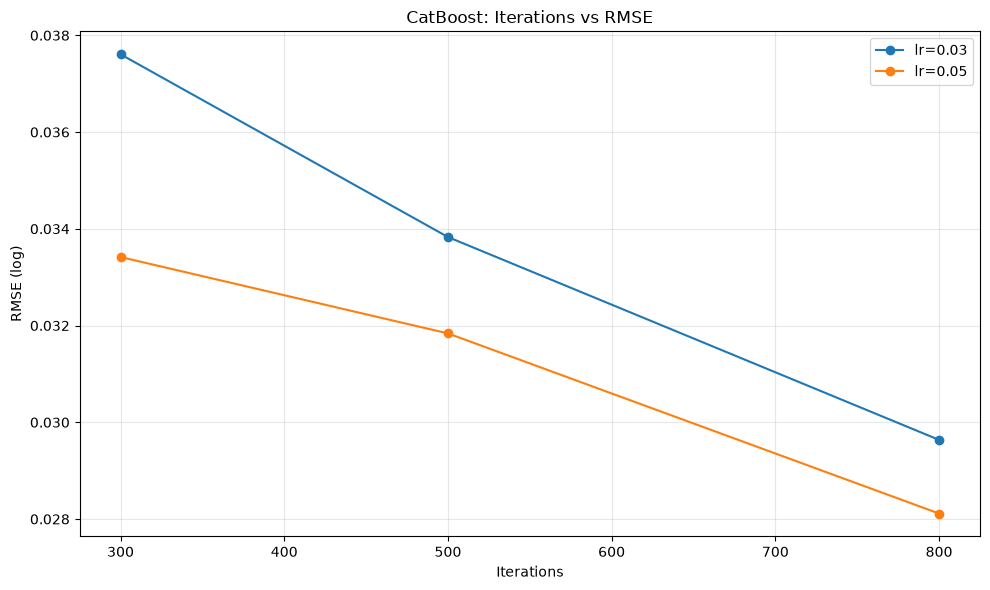

✅ CatBoost done!


In [ ]:


# --- 1. Hyperparameter search (faster) ---
cat_params = {
    'iterations': [300, 500, 800],
    'learning_rate': [0.03, 0.05, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5]
}

cat_search = RandomizedSearchCV(
    estimator=CatBoostRegressor(
        random_seed=42,
        verbose=False,
        loss_function='RMSE',
        early_stopping_rounds=50,   # <-- stops early if no improvement
        eval_metric='RMSE'
    ),
    param_distributions=cat_params,
    n_iter=10,
    scoring='neg_root_mean_squared_error',
    cv=3,
    random_state=42,
    n_jobs=-1,                      # <-- use all CPU cores
    verbose=2
)

cat_search.fit(x_train_final, y_train_final)

cat_best = cat_search.best_estimator_
cat_pred = cat_best.predict(x_val)

joblib.dump(cat_best, 'catboost_model.pkl')

print("Best parameters:", cat_search.best_params_)
print("Best CV RMSE:", -cat_search.best_score_)

# --- 3. Validation metrics ---
cat_rmse_log = np.sqrt(mean_squared_error(y_val, cat_pred))
cat_rmse_orig = np.sqrt(mean_squared_error(np.expm1(y_val), np.expm1(cat_pred)))
cat_r2 = r2_score(y_val, cat_pred)

print(f"\nRMSE (log): {cat_rmse_log:.6f}")
print(f"RMSE (original): {cat_rmse_orig:,.0f}")
print(f"R²: {cat_r2:.6f}")

# --- 4. Save results ---
cat_results = pd.DataFrame(cat_search.cv_results_)
cat_results['rmse'] = -cat_results['mean_test_score']
cat_results.to_csv('gridsearch_catboost.csv', index=False)

# --- 5. Plot ---
plt.figure(figsize=(10, 6))
for lr in cat_results['param_learning_rate'].dropna().unique():
    subset = cat_results[cat_results['param_learning_rate'] == lr]
    if len(subset) > 0:
        grouped = subset.groupby('param_iterations')['rmse'].mean()
        plt.plot(grouped.index, grouped.values, marker='o', label=f'lr={lr}')

plt.xlabel('Iterations')
plt.ylabel('RMSE (log)')
plt.title('CatBoost: Iterations vs RMSE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('catboost_elbow.png')
plt.show()

print("✅ CatBoost done!")

🌿 LightGBM RandomizedSearch starting...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best Params: {'subsample': 0.7, 'num_leaves': 31, 'n_estimators': 800, 'max_depth': 12, 'learning_rate': 0.05, 'bagging_freq': 5}
Best CV RMSE: 0.033318
RMSE (log): 0.021530
RMSE (original): 198,917
R²: 0.998572


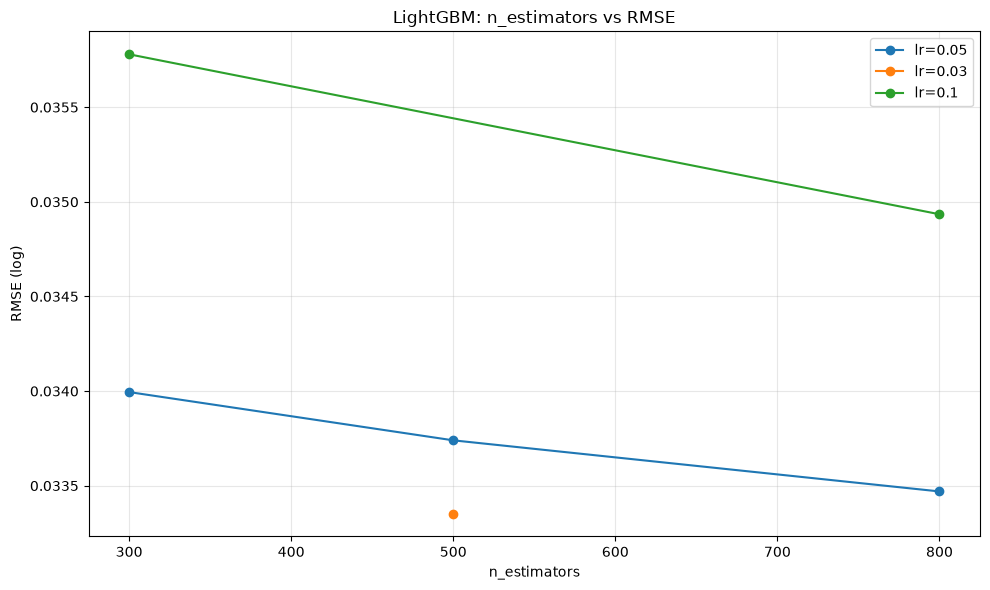

✅ LightGBM done!


In [ ]:


print("🌿 LightGBM RandomizedSearch starting...")

lgb_params = {
    'n_estimators': [300, 500, 800],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [8, 10, 12, -1],      # -1 = unlimited; 8+ ensures 2^max_depth > 100
    'num_leaves': [31, 50, 100],
    'subsample': [0.7, 0.8, 0.9],
    'bagging_freq': [5]                 # REQUIRED when subsample < 1.0
}

lgb_search = RandomizedSearchCV(
    estimator=lgb.LGBMRegressor(
        random_state=42, 
        verbose=-1, 
        n_jobs=1               # Let RandomizedSearchCV handle parallelism
    ),
    param_distributions=lgb_params,
    n_iter=10,
    scoring='neg_root_mean_squared_error',
    cv=3,
    random_state=42,
    n_jobs=-1,                 # Parallelize across parameter combinations
    verbose=2,
    error_score='raise'        # Show exact error immediately if something still fails
)

def _sanitize_cols(df):
    cols = []
    seen = {}
    for col in df.columns:
        c = re.sub(r'[^0-9a-zA-Z_]', '_', str(col))
        c = re.sub(r'_+', '_', c).strip('_')
        if c == '':
            c = 'col'
        # make unique
        if c in seen:
            seen[c] += 1
            c = f"{c}_{seen[c]}"
        else:
            seen[c] = 0
        cols.append(c)
    df.columns = cols

# sanitize training/validation (and test if available) feature names to remove special JSON characters
for name in ['x_train_final', 'x_val', 'x_train_encoded', 'x_test_encoded']:
    if name in globals():
        _sanitize_cols(globals()[name])

lgb_search.fit(x_train_final, y_train_final)

# ========== Best Model ==========
lgb_best = lgb_search.best_estimator_
lgb_pred = lgb_best.predict(x_val)

lgb_rmse_log = np.sqrt(mean_squared_error(y_val, lgb_pred))
lgb_rmse_orig = np.sqrt(mean_squared_error(np.expm1(y_val), np.expm1(lgb_pred)))
lgb_r2 = r2_score(y_val, lgb_pred)

print(f"\nBest Params: {lgb_search.best_params_}")
print(f"Best CV RMSE: {-lgb_search.best_score_:.6f}")
print(f"RMSE (log): {lgb_rmse_log:.6f}")
print(f"RMSE (original): {lgb_rmse_orig:,.0f}")
print(f"R²: {lgb_r2:.6f}")

# ========== Save Results ==========
lgb_results = pd.DataFrame(lgb_search.cv_results_)
lgb_results['rmse'] = -lgb_results['mean_test_score']
lgb_results.to_csv('gridsearch_lightgbm.csv', index=False)
joblib.dump(lgb_best, 'lightgbm_model.pkl')

# ========== Plot ==========
plt.figure(figsize=(10, 6))
for lr in lgb_results['param_learning_rate'].dropna().unique():
    subset = lgb_results[lgb_results['param_learning_rate'] == lr]
    if len(subset) > 0:
        grouped = subset.groupby('param_n_estimators')['rmse'].mean()
        plt.plot(grouped.index, grouped.values, marker='o', label=f'lr={lr}')

plt.xlabel('n_estimators')
plt.ylabel('RMSE (log)')
plt.title('LightGBM: n_estimators vs RMSE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lightgbm_elbow.png')
plt.show()

print("✅ LightGBM done!")

   Model     RMSE       R²
CatBoost 0.017569 0.999049
LightGBM 0.021530 0.998572
 XGBoost 0.021670 0.998553


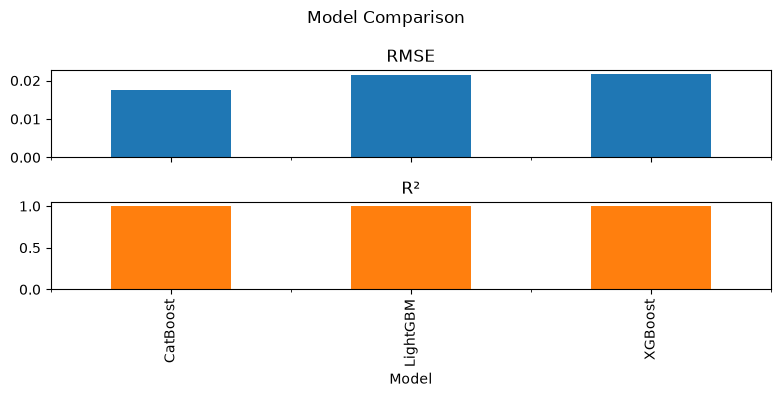

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

xgb_pred = y_pred_log

models = {
    'CatBoost': cat_pred,
    'LightGBM': lgb_pred,
    'XGBoost': xgb_pred
}

comparison = []
for name, pred in models.items():
    rmse = np.sqrt(mean_squared_error(y_val, pred))
    r2 = r2_score(y_val, pred)
    comparison.append({'Model': name, 'RMSE': rmse, 'R²': r2})

df = pd.DataFrame(comparison)
print(df.to_string(index=False))

# رسم بسيط
df.plot(x='Model', y=['RMSE', 'R²'], kind='bar', subplots=True, figsize=(8,4), legend=False)
plt.suptitle('Model Comparison')
plt.tight_layout()
plt.show()